# Non-Uniform Radial Poisson Solver:
# Outer Boundary Layer Problem ($r \to R$)

$$
u(r,\theta)
=
\left(1 - e^{\lambda \left(\frac{r^2}{R^2}-1\right)}\right)
\left(\frac{r}{R}\right)^m
\cos\left(m(\theta-\theta_0)\right)
$$

This manufactured Poisson problem models physical phenomena with steep boundary layers near $r = R$, satisfying homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

### Theoretical Principle & Radial Nonuniformity Motivation:
- **Azimuthal Direction (Uniform is Optimal)**: Equispaced sampling in $\theta$ uniquely achieves exact trigonometric interpolation with optimal spectral accuracy and matrix conditioning ($\,\kappa=1\,$). Nonuniform placement in $\theta$ cannot improve accuracy at fixed $N$. In fact, for a single harmonic mode $m=4$, $N=32$ resolves the Fourier coefficients to machine precision (zero angular error).
- **Radial Direction (Nonuniform Beats Uniform at Fixed $M$)**: Radial integration is a local 1D polynomial quadrature rule (Trapezoidal/Simpson) combined with recurrences. Local quadrature truncation error is governed by local derivative behavior. When steep gradients concentrate near $r=R$, uniform spacing wastes grid points in flat interior regions while under-resolving the boundary rim. Concentrating radial nodes near $r=R$ minimizes quadrature error for a fixed radial node budget $M$ at **zero computational cost overhead**.

In [1]:
import os
import sys
import platform
import psutil
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = True  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters
# Fixed Angular Grid Resolution (Resolves theta mode to machine precision)
N = 32
num_processors = None    # Number of CPU threads (None = all available cores)

from nonuniform_radial_helpers import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

backend_name = 'GPU (NVIDIA CuPy / cuFINUFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY')
print('=' * 75)
print(f'  Active Backend  : {backend_name}')
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

if USE_GPU:
    try:
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
        compute_cap = f"{props['major']}.{props['minor']}"
        free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
        
        print('-' * 75)
        print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
        print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
        print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    except Exception as e:
        print(f'  GPU Status      : Warning - GPU query failed: {e}')

print(f'  Time Trials     : {TIME_TRIALS} (Runs = {NUM_RUNS})')
print('=' * 75)


  BENCHMARK ENVIRONMENT SUMMARY
  Active Backend  : GPU (NVIDIA CuPy / cuFINUFFT)
  Environment     : Google Colab (Linux 6.6.122+)
  Host CPU        : Intel(R) Xeon(R) CPU @ 2.20GHz
  CPU Cores       : 6 Physical / 12 Logical Threads
  System RAM      : 53.0 GB Total (51.0 GB Available)
---------------------------------------------------------------------------
  GPU Device      : NVIDIA L4 (Compute Capability: 8.9)
  GPU VRAM        : 22.0 GB Total (21.6 GB Free)
  CUDA Driver/RT  : 12090
  Time Trials     : True (Runs = 5)


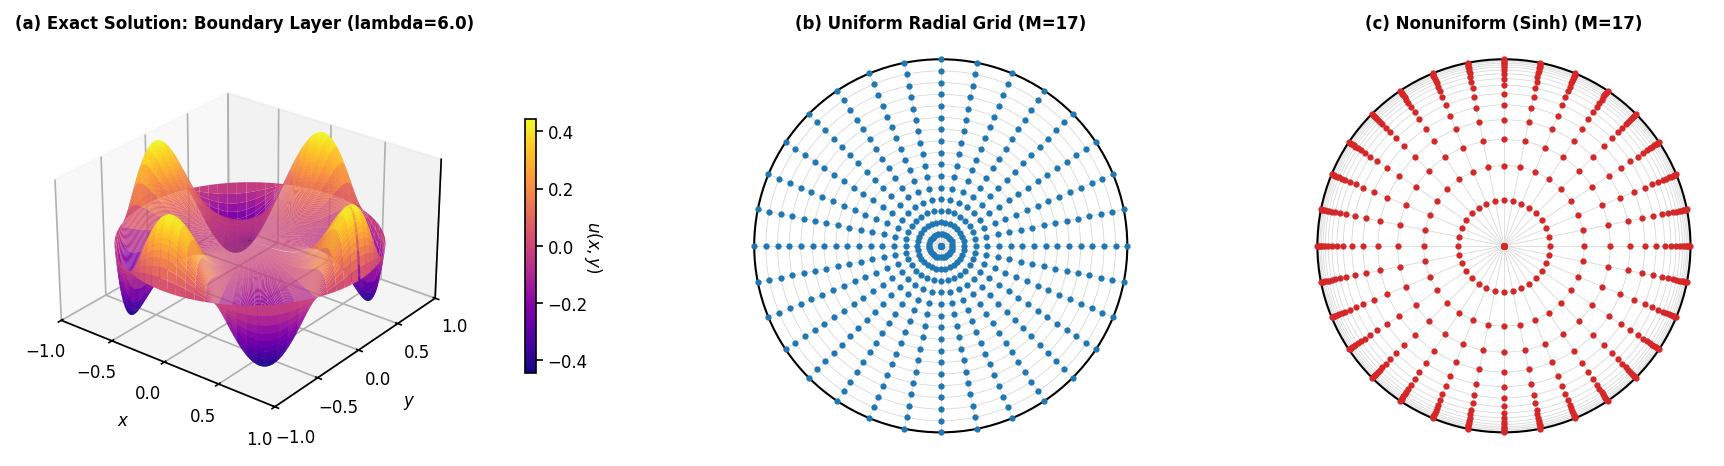

In [2]:
# Problem Setup: Outer Boundary Layer (lambda = 6.0, mode = 4)
R = 1.0
mode = 4
lambda_param = 6.0
problem = get_boundary_layer_problem(R=R, mode=mode, lambda_param=lambda_param)

# Journal-style 1 x 3 visualization of solution and radial meshes
plot_solution_and_radial_grids(
    problem=problem,
    N=N,
    M=17,
    primary_kind="sinh",
    primary_label="Adapted Boundary Radial (Sinh)"
)


## Radial Refinement ($M$-sweep) Benchmark Study & Performance Profiles

With the angular resolution fixed at $N = 32$, we perform a radial refinement sweep over $M \in \{9, 17, 25, 33, 49, 65, 97, 129, 257\}$.
Tabular benchmarks display **Accuracies first** and **Runtimes last**.

In [3]:
M_dense = [9, 17, 25, 33, 49, 65, 97, 129, 257]
rad_kinds = [
    ("uniform", "Uniform Radial"),
    ("sinh", "Adapted Nonuniform (Sinh)"),
    ("chebyshev_lobatto", "Chebyshev-Lobatto"),
]

# Execute Radial Grid Sweep for Fixed N = 32
df_fixed_n = run_radial_grid_sweep(problem, N=N, M_values=M_dense, rad_kinds=rad_kinds, quad_rule=2, bc_choice=1, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS)

# 1. Accuracy Table (Fixed N=32, Varying M) (FIRST)
render_fixed_n_accuracy_table(df_fixed_n, title=f"Table 1: Relative Errors for Fixed N = {N} with Varying Radial Points M")

# 2. Runtime Table (Fixed N=32, Varying M) (LAST)
render_fixed_n_runtime_table(df_fixed_n, title=f"Table 2: Solve Runtimes (ms) for Fixed N = {N} with Varying Radial Points M")


Radial M-sweep (Boundary Layer (lambda=6.0)) [GPU]:   0%|          | 0/27 [00:00<?, ?it/s]

rad_kind,Uniform Radial,Chebyshev-Lobatto,Nonuniform (Sinh)
M,,,
9,5.79 ms,6.10 ms,6.13 ms
17,5.82 ms,6.20 ms,6.24 ms
25,5.81 ms,6.20 ms,6.22 ms
33,5.76 ms,6.14 ms,6.20 ms
49,5.75 ms,6.23 ms,6.20 ms
65,5.80 ms,6.31 ms,6.19 ms
97,5.75 ms,6.25 ms,6.30 ms
129,5.81 ms,6.28 ms,6.23 ms
257,6.06 ms,6.59 ms,6.56 ms


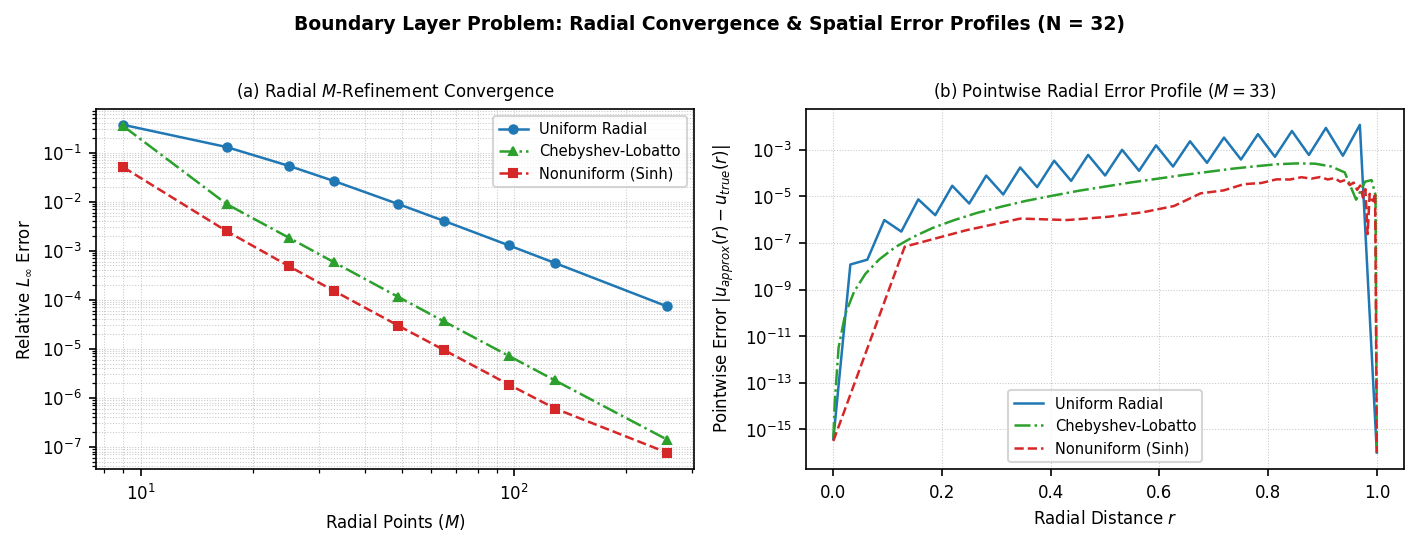

In [4]:
# Compute Radial Pointwise Error Profiles at M = 33 for Subplot (b)
M_eval = 33
results_list = []
for kind, label in rad_kinds:
    r_m = generate_custom_radial_grid(M_eval, R=R, kind=kind)
    res = run_radial_benchmark_case(N=N, M=M_eval, r_m=r_m, problem=problem, rad_kind=label, quad_rule=2, bc_choice=1, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS)
    results_list.append(res)

# Journal-style 1 x 2 Figure: (a) Log-Log M-Refinement Convergence & (b) Semilog-Y Radial Pointwise Error Profiles
plot_combined_radial_convergence_and_profiles(
    df_fixed_n=df_fixed_n,
    results_list=results_list,
    title=f"Boundary Layer Problem: Radial Convergence & Spatial Error Profiles (N = {N})"
)
